In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
df = pd.read_excel("epl_final.xlsx")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   int64 
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


ROMEO

In [143]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_excel("epl_final.xlsx", engine='openpyxl')

# =========================
# 2. TARGET
# =========================
df['Target'] = df['FullTimeResult'].map({'H': 0, 'D': 1, 'A': 2})

# =========================
# 3. SORT BY TIME (IMPORTANT FOR REALISM)
# =========================
df['MatchDate'] = pd.to_datetime(df['MatchDate'])
df = df.sort_values('MatchDate').reset_index(drop=True)

# =========================
# 4. SAFE FEATURE ENGINEERING (STABLE VERSION)
# =========================

# Attack strength (historical average)
df['HomeAttackStrength'] = df.groupby('HomeTeam')['HomeShots'].transform('mean')
df['AwayAttackStrength'] = df.groupby('AwayTeam')['AwayShots'].transform('mean')

# Defense strength
df['HomeDefenseWeakness'] = df.groupby('HomeTeam')['AwayShots'].transform('mean')
df['AwayDefenseWeakness'] = df.groupby('AwayTeam')['HomeShots'].transform('mean')

# Simple but stable goal proxy
df['GoalDiffProxy'] = df['HomeShots'] - df['AwayShots']

# =========================
# 5. CLEAN LEAKAGE FEATURES
# =========================
df = df.drop(columns=[
    'FullTimeResult',
    'FullTimeHomeGoals',
    'FullTimeAwayGoals',
    'HalfTimeHomeGoals',
    'HalfTimeAwayGoals',
    'HalfTimeResult',
    'MatchDate',
    'Season'
])

df = df.dropna()

# =========================
# 6. FEATURES / TARGET
# =========================
X = df[[
    'HomeAttackStrength',
    'AwayAttackStrength',
    'HomeDefenseWeakness',
    'AwayDefenseWeakness',
    'GoalDiffProxy'
]]

y = df['Target']

# =========================
# 7. TIME-BASED SPLIT (NO RANDOM SHUFFLE)
# =========================
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# =========================
# 8. MODEL (STABLE CONFIG)
# =========================
model = LogisticRegression(
    max_iter=5000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42  
)

model.fit(X_train, y_train)

# =========================
# 9. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 10. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 11. PROBABILITY OUTPUT
# =========================
probs = model.predict_proba(X_test)

print("\nExample Prediction Probabilities:")
print("Home Win:", probs[0][0])
print("Draw:", probs[0][1])
print("Away Win:", probs[0][2])

Accuracy: 0.4984008528784648

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.57      0.60       812
           1       0.22      0.16      0.18       429
           2       0.49      0.64      0.55       635

    accuracy                           0.50      1876
   macro avg       0.44      0.46      0.44      1876
weighted avg       0.49      0.50      0.49      1876


Confusion Matrix:

[[460 130 222]
 [156  67 206]
 [118 109 408]]

Example Prediction Probabilities:
Home Win: 0.32221105691377167
Draw: 0.33983574938856126
Away Win: 0.337953193697667


Romeo DONE

In [144]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

Dataset shape: (9380, 20)
Columns: ['HomeTeam', 'AwayTeam', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards', 'Target', 'HomeAttackStrength', 'AwayAttackStrength', 'HomeDefenseWeakness', 'AwayDefenseWeakness', 'GoalDiffProxy']

Data types:
HomeTeam                object
AwayTeam                object
HomeShots                int64
AwayShots                int64
HomeShotsOnTarget        int64
AwayShotsOnTarget        int64
HomeCorners              int64
AwayCorners              int64
HomeFouls                int64
AwayFouls                int64
HomeYellowCards          int64
AwayYellowCards          int64
HomeRedCards             int64
AwayRedCards             int64
Target                   int64
HomeAttackStrength     float64
AwayAttackStrength     float64
HomeDefenseWeakness    float64
AwayDefenseWeakness    float64
GoalDiffProxy            in

In [145]:
print("\nFirst rows:")
display(df.tail())


First rows:


,HomeTeam,AwayTeam,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,Target,HomeAttackStrength,AwayAttackStrength,HomeDefenseWeakness,AwayDefenseWeakness,GoalDiffProxy
9375,West Ham,Tottenham,11,7,2,2,1,3,18,15,2,2,0,0,1,12.820144,11.773987,12.400480,12.861407,4
9376,Chelsea,Liverpool,17,11,7,2,3,6,10,11,2,2,0,0,0,16.364606,13.668790,8.705757,10.084926,6
9377,Brentford,Man United,12,14,6,5,7,4,8,10,0,2,0,0,0,12.733333,12.660981,13.560000,12.302772,-2
9378,Brighton,Newcastle,5,13,2,5,1,4,15,10,2,1,0,0,1,14.218543,9.986079,10.735099,13.902552,-8
9379,Crystal Palace,Nott'm Forest,20,12,3,4,7,4,9,15,3,8,0,0,1,12.508197,10.535714,11.827869,15.178571,8


In [146]:
df.describe()

,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,Target,HomeAttackStrength,AwayAttackStrength,HomeDefenseWeakness,AwayDefenseWeakness,GoalDiffProxy
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288,0.836780,13.617484,10.810661,10.810661,13.617484,2.806823
std,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183,0.852554,1.927331,1.584720,1.584187,1.860508,8.227118
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.403509,6.982456,7.847966,10.084926,-26.000000
25%,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,12.196602,9.840816,9.921053,12.861407,-3.000000
50%,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000,1.000000,13.012579,10.426124,10.993023,13.902552,3.000000
75%,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000,2.000000,15.441365,11.773987,11.947368,14.900000,8.000000
max,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000,2.000000,17.531049,13.668790,15.052632,20.368421,40.000000



Numeric columns: ['HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards', 'Target', 'HomeAttackStrength', 'AwayAttackStrength', 'HomeDefenseWeakness', 'AwayDefenseWeakness', 'GoalDiffProxy']


,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,Target,HomeAttackStrength,AwayAttackStrength,HomeDefenseWeakness,AwayDefenseWeakness,GoalDiffProxy
HomeShots,1.000000,-0.336635,0.668351,-0.243231,0.483638,-0.296517,-0.151820,-0.033168,-0.105715,0.041252,-0.112555,0.096789,-0.224808,0.359817,-0.284812,-0.292658,0.347341,0.843239
AwayShots,-0.336635,1.000000,-0.263870,0.677796,-0.318202,0.481029,0.014430,-0.127033,0.122752,-0.073290,0.112691,-0.110352,0.257528,-0.274354,0.337426,0.337312,-0.276681,-0.790029
HomeShotsOnTarget,0.668351,-0.263870,1.000000,-0.045322,0.356250,-0.170833,-0.054081,0.029482,-0.142065,0.011868,-0.074763,0.091576,-0.323645,0.298503,-0.248891,-0.295621,0.212679,0.585775
AwayShotsOnTarget,-0.243231,0.677796,-0.045322,1.000000,-0.175620,0.345213,0.061108,-0.042496,0.056695,-0.060402,0.107098,-0.071342,0.321245,-0.228509,0.263552,0.212653,-0.269759,-0.545284
HomeCorners,0.483638,-0.318202,0.356250,-0.175620,1.000000,-0.254734,-0.079328,0.009185,-0.062937,0.041592,-0.065598,0.054189,-0.057625,0.210260,-0.239164,-0.215513,0.237737,0.496529
AwayCorners,-0.296517,0.481029,-0.170833,0.345213,-0.254734,1.000000,0.016905,-0.063096,0.046295,-0.047358,0.070904,-0.064249,0.048674,-0.200735,0.188971,0.200172,-0.175744,-0.467652
HomeFouls,-0.151820,0.014430,-0.054081,0.061108,-0.079328,0.016905,1.000000,0.206338,0.325781,0.091990,0.076243,0.033697,0.034550,-0.097153,0.000879,0.045037,-0.042223,-0.107083
AwayFouls,-0.033168,-0.127033,0.029482,-0.042496,0.009185,-0.063096,0.206338,1.000000,0.053750,0.349556,0.041451,0.079349,-0.030651,-0.030589,-0.107423,-0.003820,0.028230,0.050923
HomeYellowCards,-0.105715,0.122752,-0.142065,0.056695,-0.062937,0.046295,0.325781,0.053750,1.000000,0.191337,0.056275,0.035168,0.118126,-0.072010,0.123409,0.083166,-0.087444,-0.138901
AwayYellowCards,0.041252,-0.073290,0.011868,-0.060402,0.041592,-0.047358,0.091990,0.349556,0.191337,1.000000,0.068179,0.078721,-0.029195,0.054944,-0.011577,-0.041918,0.010373,0.068696


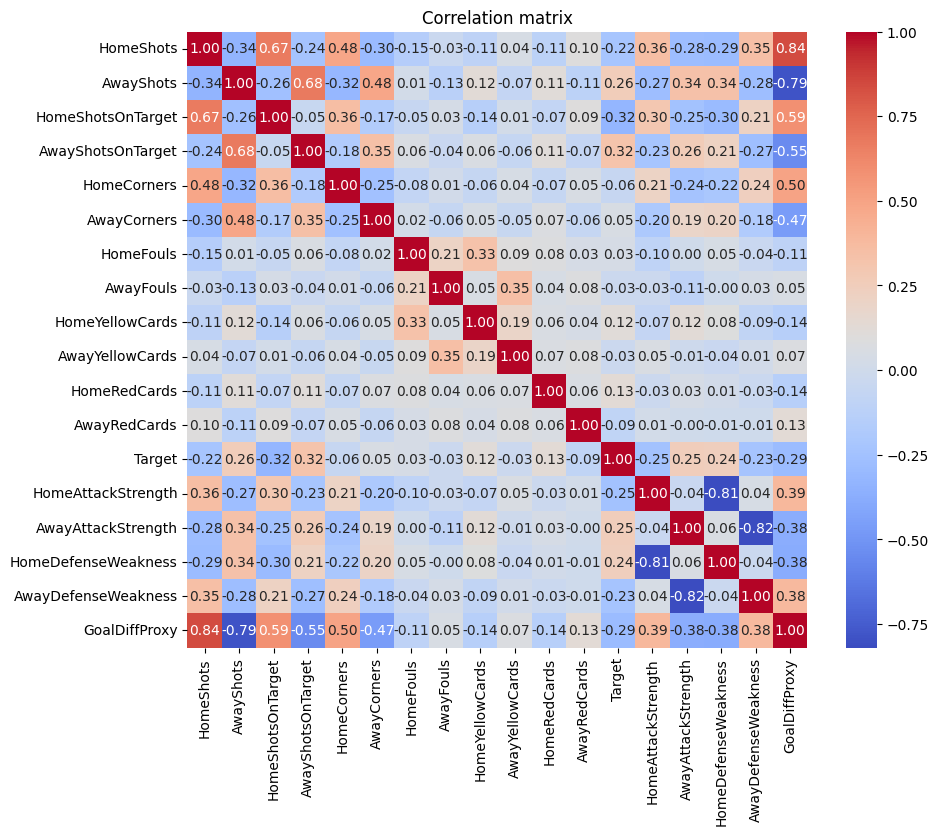

In [147]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    print("\nNumeric columns:", numeric_cols)
    corr = df[numeric_cols].corr()
    display(corr)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix")
    plt.show()
else:
    print("No numeric columns found for correlation analysis.")


In [148]:
# Check for class balance
# First, identify potential target variables (categorical columns with reasonable number of classes)
print("\n" + "="*60)
print("CHECKING DATASET BALANCE")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

# Check value counts for each categorical column
for col in categorical_cols:
    print(f"\n--- {col} ---")
    value_counts = df[col].value_counts()
    print(f"Number of classes: {len(value_counts)}")
    print(f"Distribution:\n{value_counts}")
    print(f"Percentages:\n{(value_counts/len(df)*100).round(2)}")



CHECKING DATASET BALANCE

Categorical columns: ['HomeTeam', 'AwayTeam']

--- HomeTeam ---
Number of classes: 46
Distribution:
HomeTeam
Everton             471
Chelsea             469
Tottenham           469
Man United          469
Arsenal             468
Liverpool           467
Man City            450
Newcastle           430
West Ham            417
Aston Villa         412
Fulham              335
Southampton         318
Sunderland          266
Leicester           245
Crystal Palace      244
West Brom           244
Blackburn           204
Bolton              204
Wolves              204
Stoke               190
Middlesbrough       187
Burnley             171
Wigan               152
Brighton            151
Bournemouth         150
Watford             133
Swansea             133
Leeds               131
Norwich             131
Birmingham          130
Charlton            128
Portsmouth          128
Hull                 95
Sheffield United     76
Brentford            75
Reading              57


In [149]:
# Calculate balance metrics
print("\n" + "="*60)
print("BALANCE METRICS")
print("="*60)

for col in categorical_cols:
    value_counts = df[col].value_counts()
    total = len(df)
    
    # Calculate imbalance ratio
    max_class_count = value_counts.max()
    min_class_count = value_counts.min()
    imbalance_ratio = max_class_count / min_class_count
    
    # Check for dominant class
    dominant_class_percentage = (max_class_count / total) * 100
    
    print(f"\n{col}:")
    print(f"  Imbalance Ratio: {imbalance_ratio:.2f}:1")
    print(f"  Dominant Class: {dominant_class_percentage:.2f}%")
    print(f"  Balance Status: ", end="")
    
    if imbalance_ratio < 1.5:
        print("✓ WELL BALANCED")
    elif imbalance_ratio < 3:
        print("⚠ MODERATELY IMBALANCED")
    else:
        print("✗ HIGHLY IMBALANCED")



BALANCE METRICS

HomeTeam:
  Imbalance Ratio: 24.79:1
  Dominant Class: 5.02%
  Balance Status: ✗ HIGHLY IMBALANCED

AwayTeam:
  Imbalance Ratio: 24.79:1
  Dominant Class: 5.02%
  Balance Status: ✗ HIGHLY IMBALANCED


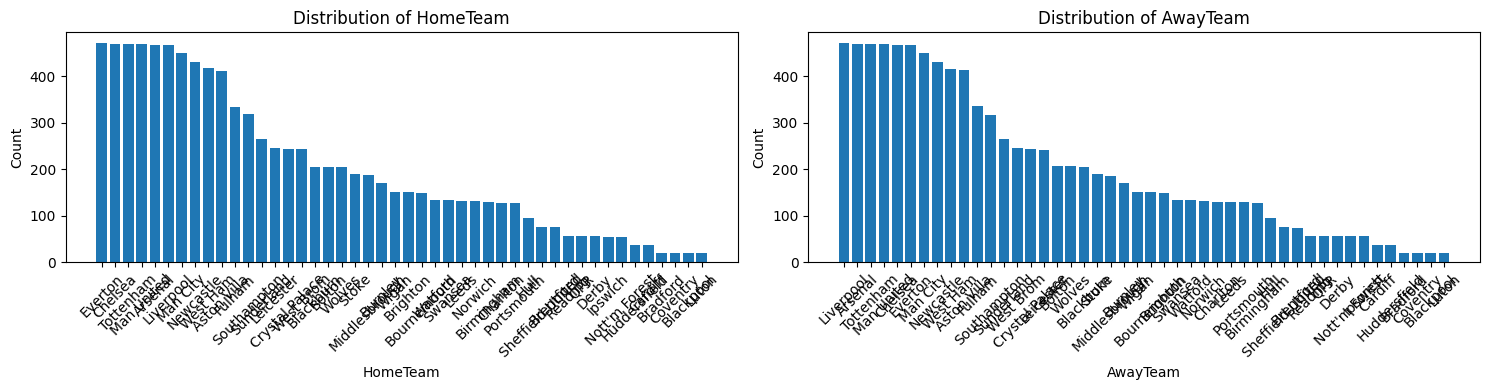

In [150]:
# Visualize class distributions
if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 4))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45)
    
    plt.tight_layout()
    plt.show()


In [151]:
# Compare Home Goals vs Away Goals
print("\n" + "="*80)
print("HOME GOALS vs AWAY GOALS ANALYSIS")
print("="*80)

# Find goal-related columns
home_goal_col = None
away_goal_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'home' in col_lower and ('goal' in col_lower or 'gf' in col_lower):
        home_goal_col = col
    if 'away' in col_lower and ('goal' in col_lower or 'gf' in col_lower):
        away_goal_col = col

if home_goal_col and away_goal_col:
    print(f"\n✓ Found columns: Home Goals = '{home_goal_col}', Away Goals = '{away_goal_col}'")
    
    home_goals = df[home_goal_col]
    away_goals = df[away_goal_col]
    
    print(f"\n📊 HOME GOALS Statistics:")
    print(f"   Mean: {home_goals.mean():.2f}")
    print(f"   Median: {home_goals.median():.2f}")
    print(f"   Std Dev: {home_goals.std():.2f}")
    print(f"   Min: {home_goals.min()}, Max: {home_goals.max()}")
    print(f"   Total: {home_goals.sum()}")
    
    print(f"\n📊 AWAY GOALS Statistics:")
    print(f"   Mean: {away_goals.mean():.2f}")
    print(f"   Median: {away_goals.median():.2f}")
    print(f"   Std Dev: {away_goals.std():.2f}")
    print(f"   Min: {away_goals.min()}, Max: {away_goals.max()}")
    print(f"   Total: {away_goals.sum()}")
    
    print(f"\n⚖️  COMPARISON:")
    mean_diff = home_goals.mean() - away_goals.mean()
    print(f"   Home Goals Mean - Away Goals Mean: {mean_diff:.4f}")
    print(f"   Home Goals Total - Away Goals Total: {home_goals.sum() - away_goals.sum()}")
    
    if abs(mean_diff) < 0.1:
        print(f"\n   ✓ EQUAL - Home and Away goals are BALANCED")
    else:
        print(f"\n   ✗ NOT EQUAL - Home team scores {'MORE' if mean_diff > 0 else 'FEWER'} goals on average")
        print(f"     Home advantage: {mean_diff:.4f} goals per match")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(home_goals, bins=20, alpha=0.7, label='Home Goals', color='blue', edgecolor='black')
    axes[0].hist(away_goals, bins=20, alpha=0.7, label='Away Goals', color='red', edgecolor='black')
    axes[0].set_xlabel('Goals Scored')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution: Home vs Away Goals')
    axes[0].legend()
    
    axes[1].boxplot([home_goals, away_goals], labels=['Home Goals', 'Away Goals'])
    axes[1].set_ylabel('Goals Scored')
    axes[1].set_title('Box Plot: Home vs Away Goals')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"\n✗ Could not find home/away goal columns")
    print(f"Available columns: {list(df.columns)}")



HOME GOALS vs AWAY GOALS ANALYSIS

✗ Could not find home/away goal columns
Available columns: ['HomeTeam', 'AwayTeam', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards', 'Target', 'HomeAttackStrength', 'AwayAttackStrength', 'HomeDefenseWeakness', 'AwayDefenseWeakness', 'GoalDiffProxy']


In [152]:
# Analyze Full Time Result Distribution
print("\n" + "="*80)
print("FULL TIME RESULT ANALYSIS")
print("="*80)

# Find FTR column
ftr_col = None
for col in df.columns:
    if 'ftr' in col.lower() or 'result' in col.lower() or ('full' in col.lower() and 'time' in col.lower()):
        ftr_col = col
        break

if ftr_col:
    print(f"\n✓ Found column: '{ftr_col}'")
    
    ftr = df[ftr_col]
    result_counts = ftr.value_counts().sort_values(ascending=False)
    total_matches = len(df)
    
    print(f"\n📊 MATCH RESULTS DISTRIBUTION:")
    print(f"   Total matches: {total_matches}")
    
    for result, count in result_counts.items():
        percentage = (count / total_matches) * 100
        bar_length = int(percentage / 2)
        bar = "█" * bar_length
        print(f"   {str(result):15} | Count: {count:5} | {percentage:6.2f}% {bar}")
    
    print(f"\n⚖️  BALANCE ANALYSIS:")
    max_result = result_counts.max()
    min_result = result_counts.min()
    imbalance_ratio = max_result / min_result if min_result > 0 else float('inf')
    
    print(f"   Most common: {result_counts.index[0]} ({result_counts.iloc[0]} matches, {(result_counts.iloc[0]/total_matches*100):.2f}%)")
    print(f"   Least common: {result_counts.index[-1]} ({result_counts.iloc[-1]} matches, {(result_counts.iloc[-1]/total_matches*100):.2f}%)")
    print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")
    
    print(f"\n🎯 VERDICT:")
    if imbalance_ratio < 1.3:
        print(f"   ✓ BALANCED - Results are evenly distributed")
    elif imbalance_ratio < 1.8:
        print(f"   ⚠ MODERATELY IMBALANCED - Some results more common than others")
    else:
        print(f"   ✗ IMBALANCED - Significant variation in result frequencies")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Bar plot
    colors = ['#2ecc71' if r == 'H' else '#e74c3c' if r == 'A' else '#3498db' for r in result_counts.index]
    axes[0].bar(range(len(result_counts)), result_counts.values, color=colors, edgecolor='black', linewidth=2)
    axes[0].set_xticks(range(len(result_counts)))
    axes[0].set_xticklabels(result_counts.index, fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Matches', fontsize=11)
    axes[0].set_title('Full Time Result Distribution', fontsize=12, fontweight='bold')
    
    for i, v in enumerate(result_counts.values):
        axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    # Pie chart
    labels = [f'{result}\n({count})' for result, count in result_counts.items()]
    axes[1].pie(result_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', 
                startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Match Result Percentages', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

else:
    print(f"\n✗ Could not find Full Time Result column")
    print(f"Available columns: {list(df.columns)}")



FULL TIME RESULT ANALYSIS

✗ Could not find Full Time Result column
Available columns: ['HomeTeam', 'AwayTeam', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards', 'Target', 'HomeAttackStrength', 'AwayAttackStrength', 'HomeDefenseWeakness', 'AwayDefenseWeakness', 'GoalDiffProxy']


## Full Time Result Codes Explained

| Code | Meaning | Explanation |
|------|---------|-------------|
| **H** | Home Win | Home team won the match |
| **A** | Away Win | Away team won the match |
| **D** | Draw | Both teams scored the same number of goals (tie) |

### Example:
- If FTR = **H**: Home team 2, Away team 1 ✓ Home Won
- If FTR = **A**: Home team 1, Away team 2 ✓ Away Won  
- If FTR = **D**: Home team 1, Away team 1 ✓ Draw/Tie


In [153]:
# Quick Count Summary
print("\n" + "="*60)
print("MATCH RESULTS COUNT SUMMARY")
print("="*60)

ftr = df['Target']
total = len(df)

h_wins = (ftr == 'H').sum()
a_wins = (ftr == 'A').sum()
draws = (ftr == 'D').sum()

print(f"\n📊 TOTAL COUNTS:")
print(f"  🏠 Home Wins (H): {h_wins:,} matches")
print(f"  ✈️  Away Wins (A): {a_wins:,} matches")
print(f"  🤝 Draws (D):      {draws:,} matches")
print(f"  {'─'*60}")
print(f"  TOTAL:            {total:,} matches")

print(f"\n📈 PERCENTAGES:")
print(f"  🏠 Home Wins: {(h_wins/total)*100:.2f}%")
print(f"  ✈️  Away Wins: {(a_wins/total)*100:.2f}%")
print(f"  🤝 Draws:     {(draws/total)*100:.2f}%")

print(f"\n✓ Verification: {h_wins} + {a_wins} + {draws} = {h_wins + a_wins + draws} ✓")



MATCH RESULTS COUNT SUMMARY

📊 TOTAL COUNTS:
  🏠 Home Wins (H): 0 matches
  ✈️  Away Wins (A): 0 matches
  🤝 Draws (D):      0 matches
  ────────────────────────────────────────────────────────────
  TOTAL:            9,380 matches

📈 PERCENTAGES:
  🏠 Home Wins: 0.00%
  ✈️  Away Wins: 0.00%
  🤝 Draws:     0.00%

✓ Verification: 0 + 0 + 0 = 0 ✓



CARDS ANALYSIS: HOME vs AWAY

📊 YELLOW CARDS ANALYSIS

🏠 HOME YELLOW CARDS:
   Total: 13,771
   Average per match: 1.47
   Min: 0, Max: 7
   Median: 1.00, Std Dev: 1.22

✈️  AWAY YELLOW CARDS:
   Total: 16,813
   Average per match: 1.79
   Min: 0, Max: 9
   Median: 2.00, Std Dev: 1.29

⚖️  YELLOW CARDS COMPARISON:
   Home avg - Away avg: -0.3243
   Home receives FEWER yellow cards on average
   Difference: 0.3243 cards per match

🔴 RED CARDS ANALYSIS

🏠 HOME RED CARDS:
   Total: 586
   Average per match: 0.06
   Min: 0, Max: 3
   Median: 0.00, Std Dev: 0.25
   Matches with red card: 561 (5.98%)

✈️  AWAY RED CARDS:
   Total: 800
   Average per match: 0.09
   Min: 0, Max: 2
   Median: 0.00, Std Dev: 0.29
   Matches with red card: 771 (8.22%)

⚖️  RED CARDS COMPARISON:
   Home avg - Away avg: -0.0228
   Home receives FEWER red cards on average
   Difference: 0.0228 cards per match

📋 SUMMARY COMPARISON

🏠 HOME TEAMS - Total Cards:
   Yellow + Red = 13,771 + 586 = 14,357
   Average per m

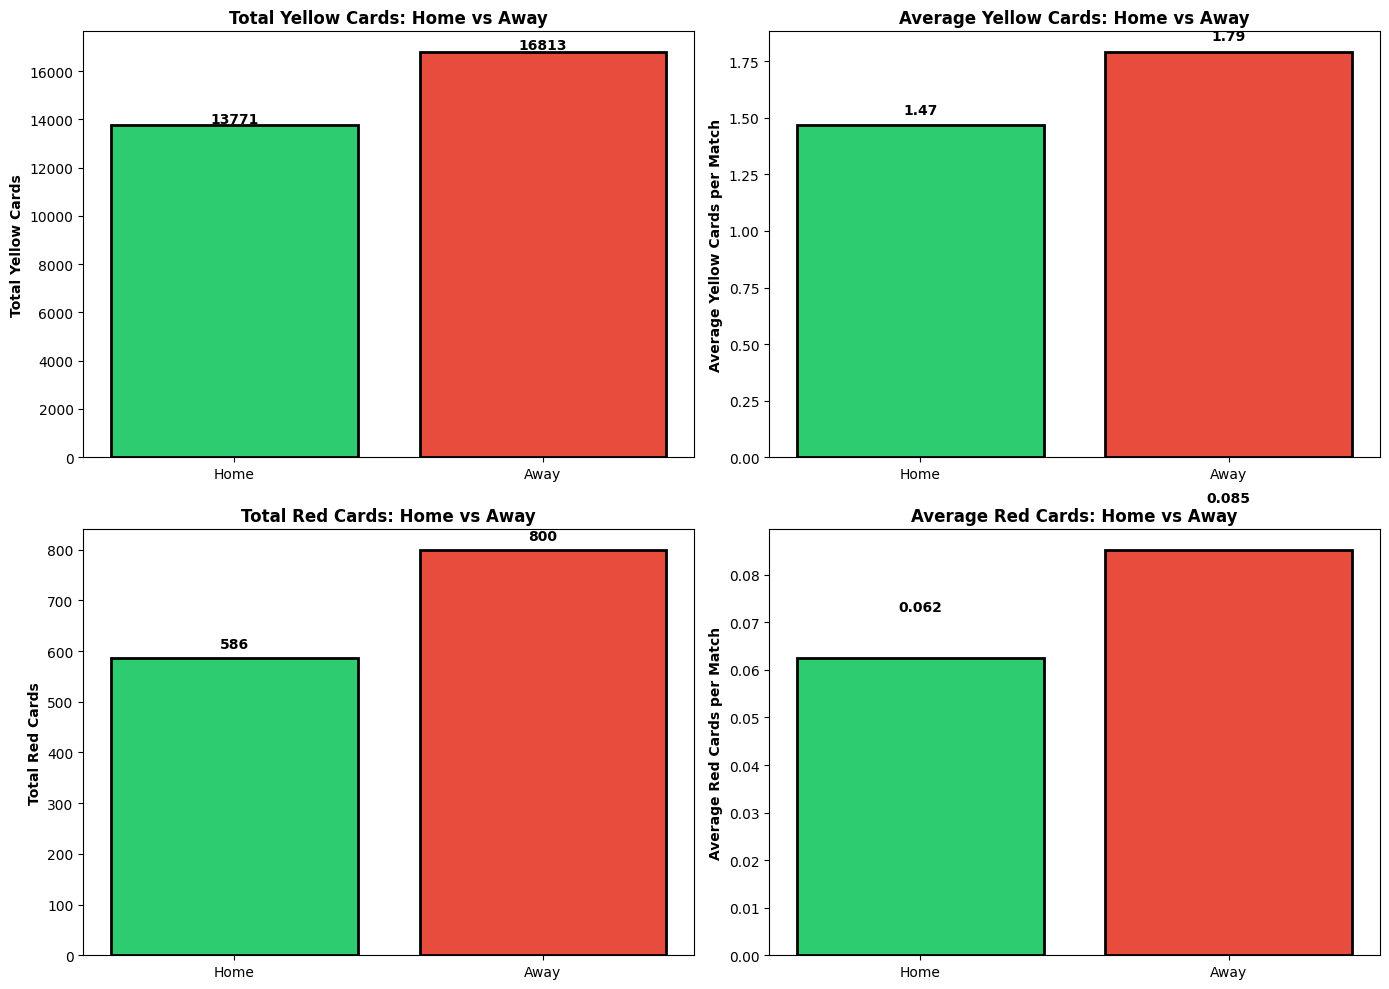

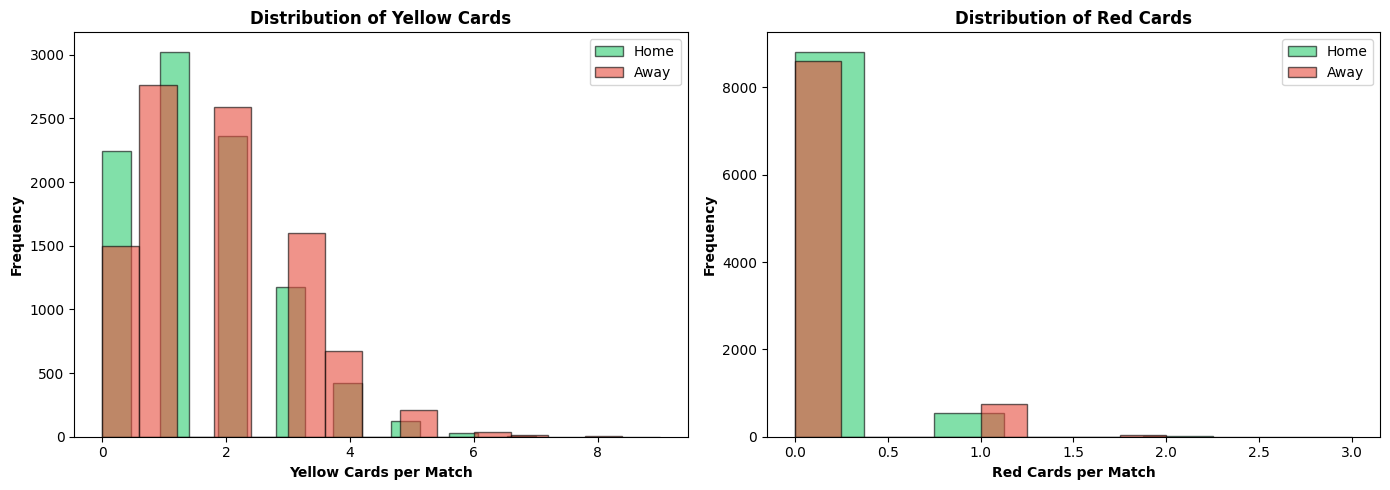

In [154]:
# Yellow and Red Cards Analysis - Home vs Away
print("\n" + "="*80)
print("CARDS ANALYSIS: HOME vs AWAY")
print("="*80)

# Get card columns
home_yellow = df['HomeYellowCards']
away_yellow = df['AwayYellowCards']
home_red = df['HomeRedCards']
away_red = df['AwayRedCards']

total_matches = len(df)

print(f"\n{'='*80}")
print("📊 YELLOW CARDS ANALYSIS")
print(f"{'='*80}")

h_yellow_total = home_yellow.sum()
a_yellow_total = away_yellow.sum()
h_yellow_avg = home_yellow.mean()
a_yellow_avg = away_yellow.mean()

print(f"\n🏠 HOME YELLOW CARDS:")
print(f"   Total: {h_yellow_total:,}")
print(f"   Average per match: {h_yellow_avg:.2f}")
print(f"   Min: {home_yellow.min()}, Max: {home_yellow.max()}")
print(f"   Median: {home_yellow.median():.2f}, Std Dev: {home_yellow.std():.2f}")

print(f"\n✈️  AWAY YELLOW CARDS:")
print(f"   Total: {a_yellow_total:,}")
print(f"   Average per match: {a_yellow_avg:.2f}")
print(f"   Min: {away_yellow.min()}, Max: {away_yellow.max()}")
print(f"   Median: {away_yellow.median():.2f}, Std Dev: {away_yellow.std():.2f}")

print(f"\n⚖️  YELLOW CARDS COMPARISON:")
yellow_diff = h_yellow_avg - a_yellow_avg
print(f"   Home avg - Away avg: {yellow_diff:.4f}")
print(f"   Home receives {'MORE' if yellow_diff > 0 else 'FEWER'} yellow cards on average")
print(f"   Difference: {abs(yellow_diff):.4f} cards per match")

print(f"\n{'='*80}")
print("🔴 RED CARDS ANALYSIS")
print(f"{'='*80}")

h_red_total = home_red.sum()
a_red_total = away_red.sum()
h_red_avg = home_red.mean()
a_red_avg = away_red.mean()

print(f"\n🏠 HOME RED CARDS:")
print(f"   Total: {h_red_total:,}")
print(f"   Average per match: {h_red_avg:.2f}")
print(f"   Min: {home_red.min()}, Max: {home_red.max()}")
print(f"   Median: {home_red.median():.2f}, Std Dev: {home_red.std():.2f}")
print(f"   Matches with red card: {(home_red > 0).sum()} ({(home_red > 0).sum()/total_matches*100:.2f}%)")

print(f"\n✈️  AWAY RED CARDS:")
print(f"   Total: {a_red_total:,}")
print(f"   Average per match: {a_red_avg:.2f}")
print(f"   Min: {away_red.min()}, Max: {away_red.max()}")
print(f"   Median: {away_red.median():.2f}, Std Dev: {away_red.std():.2f}")
print(f"   Matches with red card: {(away_red > 0).sum()} ({(away_red > 0).sum()/total_matches*100:.2f}%)")

print(f"\n⚖️  RED CARDS COMPARISON:")
red_diff = h_red_avg - a_red_avg
print(f"   Home avg - Away avg: {red_diff:.4f}")
print(f"   Home receives {'MORE' if red_diff > 0 else 'FEWER'} red cards on average")
print(f"   Difference: {abs(red_diff):.4f} cards per match")

print(f"\n{'='*80}")
print("📋 SUMMARY COMPARISON")
print(f"{'='*80}")

total_home_cards = h_yellow_total + h_red_total
total_away_cards = a_yellow_total + a_red_total
avg_home_cards = home_yellow.mean() + home_red.mean()
avg_away_cards = away_yellow.mean() + away_red.mean()

print(f"\n🏠 HOME TEAMS - Total Cards:")
print(f"   Yellow + Red = {h_yellow_total:,} + {h_red_total:,} = {total_home_cards:,}")
print(f"   Average per match: {avg_home_cards:.2f}")

print(f"\n✈️  AWAY TEAMS - Total Cards:")
print(f"   Yellow + Red = {a_yellow_total:,} + {a_red_total:,} = {total_away_cards:,}")
print(f"   Average per match: {avg_away_cards:.2f}")

print(f"\n💡 KEY INSIGHT:")
total_diff = avg_home_cards - avg_away_cards
if total_diff > 0:
    print(f"   ⚠️  Home teams receive {total_diff:.2f} MORE cards per match on average")
    print(f"   This could indicate: Home teams play more aggressively OR")
    print(f"   Away teams play more cautiously/defensively")
else:
    print(f"   ⚠️  Away teams receive {abs(total_diff):.2f} MORE cards per match on average")
    print(f"   This could indicate: Away teams need to be more aggressive OR")
    print(f"   Home teams have advantage and can play more conservatively")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Yellow cards comparison
categories = ['Home', 'Away']
yellow_totals = [h_yellow_total, a_yellow_total]
yellow_avgs = [h_yellow_avg, a_yellow_avg]

axes[0, 0].bar(categories, yellow_totals, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Total Yellow Cards', fontweight='bold')
axes[0, 0].set_title('Total Yellow Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(yellow_totals):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Yellow cards average
axes[0, 1].bar(categories, yellow_avgs, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Average Yellow Cards per Match', fontweight='bold')
axes[0, 1].set_title('Average Yellow Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(yellow_avgs):
    axes[0, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Red cards comparison
red_totals = [h_red_total, a_red_total]
red_avgs = [h_red_avg, a_red_avg]

axes[1, 0].bar(categories, red_totals, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Total Red Cards', fontweight='bold')
axes[1, 0].set_title('Total Red Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(red_totals):
    axes[1, 0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Red cards average
axes[1, 1].bar(categories, red_avgs, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Red Cards per Match', fontweight='bold')
axes[1, 1].set_title('Average Red Cards: Home vs Away', fontweight='bold', fontsize=12)
for i, v in enumerate(red_avgs):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(home_yellow, bins=15, alpha=0.6, label='Home', color='#2ecc71', edgecolor='black')
axes[0].hist(away_yellow, bins=15, alpha=0.6, label='Away', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Yellow Cards per Match', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Yellow Cards', fontweight='bold', fontsize=12)
axes[0].legend()

axes[1].hist(home_red, bins=8, alpha=0.6, label='Home', color='#2ecc71', edgecolor='black')
axes[1].hist(away_red, bins=8, alpha=0.6, label='Away', color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Red Cards per Match', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of Red Cards', fontweight='bold', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


Ahmed

In [155]:
print(df.columns.tolist())

['HomeTeam', 'AwayTeam', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards', 'Target', 'HomeAttackStrength', 'AwayAttackStrength', 'HomeDefenseWeakness', 'AwayDefenseWeakness', 'GoalDiffProxy']


In [156]:
# The Target column is already encoded in df from CELL INDEX 2
# FullTimeResult was already dropped, so we use the existing Target column
y = df["Target"]

In [157]:
from sklearn.preprocessing import OneHotEncoder

# OneHot for HomeTeam and AwayTeam only (Season has been dropped already)
categorical_cols = ["HomeTeam", "AwayTeam"]
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Merge everything - use the existing X which already has the features we need
X_encoded = pd.concat([X, encoded_df], axis=1)

In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
X = df.drop(["HomeTeam", "AwayTeam", "Target"], axis=1)
y_home = df["FullTimeHomeGoals"] if "FullTimeHomeGoals" in df.columns else pd.read_excel("epl_final.xlsx")["FullTimeHomeGoals"].iloc[df.index]
y_away = df["FullTimeAwayGoals"]
X = pd.get_dummies(X)
X = X.fillna(0)  

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_home_train, y_home_test = y_home.iloc[:split_index], y_home.iloc[split_index:]
y_away_train, y_away_test = y_away.iloc[:split_index], y_away.iloc[split_index:]

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

home_model = DecisionTreeRegressor(max_depth=10, random_state=42)
away_model = DecisionTreeRegressor(max_depth=10, random_state=42)

home_model.fit(X_train, y_home_train)
away_model.fit(X_train, y_away_train)

y_home_pred = home_model.predict(X_test)
y_away_pred = away_model.predict(X_test)

y_home_pred_int = np.round(y_home_pred).astype(int)
y_away_pred_int = np.round(y_away_pred).astype(int)

print("=== Home Goals Evaluation ===")
print("MSE:", mean_squared_error(y_home_test, y_home_pred))
print("MAE:", mean_absolute_error(y_home_test, y_home_pred))
print("R²:", r2_score(y_home_test, y_home_pred))

print("\n=== Away Goals Evaluation ===")
print("MSE:", mean_squared_error(y_away_test, y_away_pred))
print("MAE:", mean_absolute_error(y_away_test, y_away_pred))
print("R²:", r2_score(y_away_test, y_away_pred))

print("\nSample Predictions (first 5 rows):")
for i in range(5):
    print(f"Predicted: {y_home_pred_int[i]} - {y_away_pred_int[i]}, Actual: {y_home_test.iloc[i]} - {y_away_test.iloc[i]}")


=== Home Goals Evaluation ===
MSE: 1.2505614813650974
MAE: 0.8439107783156369
R²: 0.3180334292773954

=== Away Goals Evaluation ===
MSE: 1.0964682735253948
MAE: 0.7925440267851384
R²: 0.284100425117474

Sample Predictions (first 5 rows):
Predicted: 1 - 1, Actual: 1 - 3
Predicted: 1 - 1, Actual: 0 - 2
Predicted: 4 - 1, Actual: 5 - 0
Predicted: 1 - 2, Actual: 1 - 3
Predicted: 1 - 1, Actual: 3 - 1


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Drop leakage columns
X = df.drop([
    "FullTimeResult", "FullTimeHomeGoals", "FullTimeAwayGoals",
    "HalfTimeResult", "HalfTimeHomeGoals", "HalfTimeAwayGoals"
], axis=1)

y_home = df["FullTimeHomeGoals"]
y_away = df["FullTimeAwayGoals"]

# Encode categorical features
X = pd.get_dummies(X)
X = X.fillna(0)

# Train/test split
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_home_train, y_home_test = y_home.iloc[:split_index], y_home.iloc[split_index:]
y_away_train, y_away_test = y_away.iloc[:split_index], y_away.iloc[split_index:]

# Random Forest regressors
home_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
away_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

home_model.fit(X_train, y_home_train)
away_model.fit(X_train, y_away_train)

# Predictions
y_home_pred = home_model.predict(X_test)
y_away_pred = away_model.predict(X_test)

# Round to integers (goals must be whole numbers)
y_home_pred_int = np.round(y_home_pred).astype(int)
y_away_pred_int = np.round(y_away_pred).astype(int)

# Evaluation
print("=== Home Goals Evaluation ===")
print("MSE:", mean_squared_error(y_home_test, y_home_pred))
print("MAE:", mean_absolute_error(y_home_test, y_home_pred))
print("R²:", r2_score(y_home_test, y_home_pred))

print("\n=== Away Goals Evaluation ===")
print("MSE:", mean_squared_error(y_away_test, y_away_pred))
print("MAE:", mean_absolute_error(y_away_test, y_away_pred))
print("R²:", r2_score(y_away_test, y_away_pred))

# Sample predictions
print("\nSample Predictions (first 5 rows):")
for i in range(5):
    print(f"Predicted: {y_home_pred_int[i]} - {y_away_pred_int[i]}, Actual: {y_home_test.iloc[i]} - {y_away_test.iloc[i]}")

=== Home Goals Evaluation ===
MSE: 1.191530426428477
MAE: 0.8547474116019871
R²: 0.3502247343040946

=== Away Goals Evaluation ===
MSE: 0.9745116033922031
MAE: 0.749193821525206
R²: 0.36372765228905724

Sample Predictions (first 5 rows):
Predicted: 2 - 2, Actual: 1 - 3
Predicted: 1 - 1, Actual: 0 - 2
Predicted: 4 - 1, Actual: 5 - 0
Predicted: 1 - 2, Actual: 1 - 3
Predicted: 1 - 1, Actual: 3 - 1


ROMEO HERE

In [163]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# 1. LOAD
# =========================
df = pd.read_excel("epl_final.xlsx", engine='openpyxl')

# =========================
# 2. TARGET
# =========================
df['Target'] = df['FullTimeResult'].map({'H': 0, 'D': 1, 'A': 2})

# =========================
# 3. SORT
# =========================
df['MatchDate'] = pd.to_datetime(df['MatchDate'])
df = df.sort_values('MatchDate')

# =========================
# 4. ADD TEAM ENCODING (IMPORTANT FIX)
# =========================
df = pd.get_dummies(df, columns=['HomeTeam', 'AwayTeam'])

# =========================
# 5. FEATURE ENGINEERING (SAFE)
# =========================

df['HomeShotsAdv'] = df['HomeShots']
df['AwayShotsAdv'] = df['AwayShots']

df['GoalDiffProxy'] = df['HomeShots'] - df['AwayShots']

df['HomeForm'] = df.groupby(df.filter(like='HomeTeam_').idxmax(axis=1))['Target'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['AwayForm'] = df.groupby(df.filter(like='AwayTeam_').idxmax(axis=1))['Target'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# =========================
# 6. CLEAN DATA
# =========================
df = df.drop(columns=[
    'Season',
    'FullTimeResult',
    'FullTimeHomeGoals',
    'FullTimeAwayGoals',
    'HalfTimeHomeGoals',
    'HalfTimeAwayGoals',
    'HalfTimeResult',
    'MatchDate'
])

df = df.dropna()

# =========================
# 7. SPLIT
# =========================
X = df.drop(columns=['Target'])
y = df['Target']

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# =========================
# 8. MODEL
# =========================
model = LogisticRegression(
    max_iter=5000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# =========================
# 9. PREDICT
# =========================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5510204081632653

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.56      0.63       805
           1       0.31      0.41      0.35       427
           2       0.60      0.63      0.62       630

    accuracy                           0.55      1862
   macro avg       0.54      0.53      0.53      1862
weighted avg       0.58      0.55      0.56      1862


Confusion Matrix:

[[454 229 122]
 [113 175 139]
 [ 72 161 397]]


ROMEO DONE